Summary of Usage:
This set of imports is typically used when:

You are building a custom semantic segmentation model or image processing pipeline using Keras/TensorFlow.

Conv2D, BatchNormalization, Activation, UpSampling2D, Add, and Concatenate are used to define custom architectures like U-Net, DeepLabV3+, or other encoder-decoder networks.

Adam is the optimizer used during training.

Sequence helps you implement custom data generators to efficiently feed data during training (especially for large datasets).

load_img and img_to_array are utilities to load and preprocess image files.

train_test_split allows you to easily split your dataset into training and validation/test subsets.

In [ ]:
# Import necessary modules
import os  # For interacting with the operating system (e.g., file paths)
import numpy as np  # For numerical operations, especially on arrays

# Import TensorFlow and Keras components
import tensorflow as tf
from tensorflow.keras.models import Model  # Base class for defining models
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, 
                                     Activation, UpSampling2D, Add, Concatenate)
# Layers used for building custom CNN architectures

from tensorflow.keras.optimizers import Adam  # Adam optimizer for training
from tensorflow.keras.utils import Sequence  # Base class for data generators
from tensorflow.keras import backend as K  # Backend functions for advanced operations

# Image preprocessing functions
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Train/test splitting function from Scikit-learn
from sklearn.model_selection import train_test_split


Summary:
This generator helps load images and optional masks from directories in batches.

It resizes and normalizes images.

If masks are not provided or missing, dummy masks are used (useful for inference).

It extends keras.utils.Sequence for efficient multi-threaded batch processing.

In [ ]:
# Data Generator for PNG images compatible with Keras model training
class PNGDataGenerator(Sequence):
    def __init__(self, image_dir, mask_dir=None, batch_size=8, img_size=(128, 128), shuffle=True):
        # Initialize parameters
        self.image_dir = image_dir  # Directory containing input images
        self.mask_dir = mask_dir  # Directory containing corresponding masks (optional)
        self.batch_size = batch_size  # Number of samples per batch
        self.img_size = img_size  # Target image size (height, width)
        self.shuffle = shuffle  # Whether to shuffle data each epoch
        self.image_files = sorted(os.listdir(image_dir))  # Sorted list of image filenames
        self.mask_files = sorted(os.listdir(mask_dir)) if mask_dir else None  # Sorted list of mask filenames (if provided)
        self.on_epoch_end()  # Shuffle indices at initialization if needed

    def __len__(self):
        # Return the number of batches per epoch
        return int(np.floor(len(self.image_files) / self.batch_size))

    def on_epoch_end(self):
        # Shuffle indices after each epoch to prevent model from overfitting
        self.indices = np.arange(len(self.image_files))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        # Generate one batch of data
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]  # Indices for the current batch
        batch_images = [self.image_files[k] for k in indices]  # Get the corresponding filenames

        images = []  # List to store loaded images
        masks = []   # List to store loaded masks

        for i, img_file in enumerate(batch_images):
            # Load and normalize the image
            img = load_img(os.path.join(self.image_dir, img_file), target_size=self.img_size)
            img = img_to_array(img) / 255.0  # Scale pixel values to [0, 1]
            images.append(img)

            if self.mask_dir and img_file in self.mask_files:
                # Load and normalize the corresponding grayscale mask
                mask = load_img(os.path.join(self.mask_dir, img_file), target_size=self.img_size, color_mode="grayscale")
                mask = img_to_array(mask) / 255.0  # Scale pixel values to [0, 1]
                masks.append(mask)
            else:
                # If no mask is found, create a dummy zero mask (e.g., for testing or prediction)
                masks.append(np.zeros((*self.img_size, 1)))

        return np.array(images), np.array(masks)  # Return batch as numpy arrays


Summary:
This generator helps load images and optional masks from directories in batches.

It resizes and normalizes images.

If masks are not provided or missing, dummy masks are used (useful for inference).

It extends keras.utils.Sequence for efficient multi-threaded batch processing.

In [ ]:
# Context Guided Block (CG Block)
def context_guided_block(input_tensor, out_channels):
    # Local feature extraction using a standard 3x3 convolution
    local = Conv2D(out_channels, kernel_size=3, padding='same')(input_tensor)
    local = BatchNormalization()(local)  # Normalize feature maps
    local = Activation('relu')(local)    # Apply ReLU activation

    # Context feature extraction using dilated convolution (captures wider spatial context)
    context = Conv2D(out_channels, kernel_size=3, dilation_rate=2, padding='same')(input_tensor)
    context = BatchNormalization()(context)  # Normalize context features
    context = Activation('relu')(context)    # Apply ReLU activation

    # Fuse local and context features using element-wise addition
    fused = Add()([local, context])
    
    # Final activation after fusion
    return Activation('relu')(fused)


Key Features:
High + Low Resolution Fusion: Simulates the core idea of HRNet, where multi-resolution feature branches are maintained and fused.

Simple and Lightweight: This version avoids full parallel multi-branch complexities but keeps the essence of resolution fusion.

Final Output: A binary mask for segmentation (sigmoid activation on a single-channel output).

In [ ]:
# Import required Keras components
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Input, Concatenate, UpSampling2D
from tensorflow.keras.models import Model

# Basic Conv -> BN -> ReLU block
def conv_bn_relu(x, filters, kernel_size=3, dilation_rate=1):
    x = Conv2D(filters, kernel_size=kernel_size, padding='same', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    return Activation('relu')(x)

# HRNet-style block with parallel high-res and low-res branches
def hrnet_block(input_tensor):
    # High-resolution branch: preserves spatial detail
    high_res = conv_bn_relu(input_tensor, 64)
    high_res = conv_bn_relu(high_res, 64)

    # Low-resolution branch: downsample and process with more filters
    low_res = Conv2D(128, kernel_size=3, strides=2, padding='same')(input_tensor)
    low_res = BatchNormalization()(low_res)
    low_res = Activation('relu')(low_res)
    low_res = conv_bn_relu(low_res, 128)

    # Upsample the low-resolution features to match high-res size
    low_res_up = UpSampling2D(size=(2, 2), interpolation='bilinear')(low_res)

    # Fuse both resolutions by concatenation
    fused = Concatenate()([high_res, low_res_up])
    
    # Blend the fused features
    fused = conv_bn_relu(fused, 64)
    return fused

# Build the full HRNet-style segmentation model
def HRNet(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)

    # Initial convolution
    x = conv_bn_relu(inputs, 64)

    # Apply two HRNet blocks
    x = hrnet_block(x)
    x = hrnet_block(x)

    # Final segmentation head:
    #   - 3x3 Conv + ReLU to refine features
    #   - 1x1 Conv with sigmoid to get binary segmentation mask
    x = Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = Conv2D(1, kernel_size=1, activation='sigmoid')(x)  # Output: single-channel probability map

    # Define and return the model
    return Model(inputs=inputs, outputs=x)


Key Points:
Why use Dice Loss? It's especially useful in imbalanced segmentation problems (e.g., small foreground vs large background).

smooth=1e-6: Avoids division by zero.

dice_coefficient: Can be used as a metric to track performance during training.

In [ ]:
# Dice Loss for binary segmentation tasks
def dice_loss(y_true, y_pred, smooth=1e-6):
    # Flatten predictions and ground truth
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    # Calculate intersection
    intersection = K.sum(y_true_f * y_pred_f)
    
    # Dice coefficient loss formula (1 - Dice score)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Dice Coefficient metric (higher is better, 1.0 = perfect overlap)
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Ensure true labels are float32 (important for multiplication)
    y_true_f = K.cast(y_true, dtype='float32')
    
    # Flatten both tensors
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true_f)
    
    # Calculate intersection
    intersection = K.sum(y_true_f * y_pred_f)
    
    # Dice coefficient formula
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


These variables will be used with your PNGDataGenerator to load and feed image-mask pairs into the model.

Make sure that:

Filenames in mask_dir exactly match those in image_dir.

Both image and mask PNG files are aligned spatially and format-wise (grayscale for masks).

In [ ]:
# Setup configuration for training the segmentation model

# Input image dimensions (height, width, channels)
input_shape = (128, 128, 3)  # Common input size for lightweight models, 3 channels = RGB

# Directory containing PNG input images for the model
image_dir = '/content/drive/MyDrive/land/landdata/landslide/image'  # Path to landslide images

# Directory containing corresponding PNG segmentation masks
mask_dir = '/content/drive/MyDrive/land/landdata/landslide/mask'   # Path to landslide masks
# If you want to run prediction only, you can set `mask_dir = None`


Loads batches of 10 image-mask pairs at a time.

Each image is resized to (128, 128) (as per the default in your PNGDataGenerator).

Normalizes pixel values to [0, 1].

Ensures shuffling after every epoch for better generalization.

In [ ]:
# Initialize the training data generator
train_gen = PNGDataGenerator(
    image_dir=image_dir,     # Path to input images
    mask_dir=mask_dir,       # Path to segmentation masks
    batch_size=10            # Number of samples per training batch
)


dice_loss helps with class imbalance in segmentation tasks.

dice_coefficient is a good indicator of overlap between predicted and true masks.

'accuracy' in segmentation just tracks pixel-wise match, which may not always reflect actual segmentation quality—so Dice is a better measure.

In [ ]:
# Instantiate the HRNet model with the defined input shape
model = HRNet(input_shape)

# Compile the model with optimizer, loss, and metrics
model.compile(
    optimizer=Adam(1e-4),         # Adam optimizer with learning rate = 0.0001
    loss=dice_loss,               # Use custom Dice Loss for segmentation (better for imbalanced data)
    metrics=['accuracy', dice_coefficient]  # Track pixel-wise accuracy and Dice Coefficient during training
)

# Print a summary of the model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ activation[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ activation_4[0][

 Total params: 854,529 (3.26 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 1,920 (7.50 KB)

Key Notes:
Batch Size: You've set the batch size to 2, which may be useful if you have limited GPU memory. Larger batches may speed up training, but require more memory.

Epochs: 50 epochs is a reasonable starting point. You may need to adjust based on model convergence or overfitting.

If you have a validation set, it's good practice to include it for monitoring model performance and avoiding overfitting.

In [ ]:
# Initialize the training data generator with batch size of 2
train_gen = PNGDataGenerator(image_dir=image_dir, mask_dir=mask_dir, batch_size=2)

# Train the model for 50 epochs using the data generator
model.fit(
    train_gen,             # Training data generator
    epochs=50,             # Number of epochs to train the model
    # Optionally, you can include validation data here if available:
    # validation_data=validation_gen,
    # validation_steps=validation_steps
)


Epoch 1/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 624s 270ms/step - accuracy: 0.8867 - dice_coefficient: 0.1125 - loss: 0.8875
Epoch 2/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9188 - dice_coefficient: 0.1312 - loss: 0.8688
Epoch 3/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9235 - dice_coefficient: 0.1354 - loss: 0.8646
Epoch 4/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9290 - dice_coefficient: 0.1517 - loss: 0.8483
Epoch 5/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9330 - dice_coefficient: 0.1503 - loss: 0.8497
Epoch 6/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9361 - dice_coefficient: 0.1544 - loss: 0.8456
Epoch 7/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9410 - dice_coefficient: 0.1647 - loss: 0.8353
Epoch 8/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9445 - dice_coefficient: 0.1669 - loss: 0.8331
Epoch 9/50
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accu

In [ ]:
# Save the trained model to a .h5 file
model.save("/content/drive/MyDrive/landslide/algorithm/HRNet/hrnet_landslide_png1.h5")


Key Comments Added:
Loading Model: Explains how the model is loaded from a .h5 file.

Data Directories: Points out where test images, ground truth masks, and results are saved.

Image Processing: Comments explain how the images and masks are processed and predictions are made.

Metrics: Pixel accuracy and IoU are calculated for each prediction.

Visualization: Generates 5-panel visualizations of the original, predicted mask, ground truth, and contours.

Side-by-Side: A simpler visualization comparing original, predicted, and ground truth masks.

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Load pre-trained model
model_path = "/content/drive/MyDrive/landslide/algorithm/HRNet/hrnet_landslide_png1.h5"
model = load_model(model_path, compile=False)  # Load the model without compiling as it's only for inference

# Directories for test data and result output
test_dir = "/content/drive/MyDrive/land test/images"  # Path to test images
mask_dir = "/content/drive/MyDrive/land test/Masks"   # Path to ground truth masks
output_dir = "/content/drive/MyDrive/landslide/algorithm/HRNet/resultsHRNet"  # Path to save results
os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

# Load image paths
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))  # List of test image paths
img_size = (128, 128)  # Image size for model input

def predict_and_visualize(image_paths, model, img_size, max_images=50):
    """
    Predict segmentation masks for input images and visualize results.
    
    Args:
        image_paths: List of paths to test images.
        model: The pre-trained model to use for predictions.
        img_size: Target size to resize input images to.
        max_images: Max number of images to process for visualization.
    """
    print(f"Testing on {len(image_paths)} images...\n")
    
    # Lists to store evaluation metrics
    avg_confidences = []
    all_accuracies = []
    all_ious = []

    for idx, img_path in enumerate(image_paths[:max_images]):  # Iterate over images
        img_name = os.path.basename(img_path)  # Extract the image name
        mask_path = os.path.join(mask_dir, img_name)  # Find the corresponding mask path

        # Load and preprocess image
        img = load_img(img_path, target_size=img_size)  # Load and resize the image
        img_array = img_to_array(img) / 255.0  # Convert image to array and normalize
        input_tensor = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Load ground truth mask
        if os.path.exists(mask_path):
            mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')  # Load and resize mask
            mask_array = img_to_array(mask).squeeze() / 255.0  # Convert mask to array and normalize
            bin_mask = (mask_array > 0.5).astype(np.uint8)  # Binarize the mask
        else:
            bin_mask = np.zeros(img_size, dtype=np.uint8)  # Create dummy mask if ground truth is not available

        # Predict the segmentation mask
        pred = model.predict(input_tensor)[0, :, :, 0]  # Predict the mask using the model
        bin_pred = (pred > 0.5).astype(np.uint8)  # Binarize the predicted mask
        avg_confidence = np.mean(pred)  # Average confidence of the prediction
        avg_confidences.append(avg_confidence)

        # Metrics: Pixel accuracy and IoU
        pixel_accuracy = np.mean(bin_pred == bin_mask)  # Pixel-wise accuracy
        all_accuracies.append(pixel_accuracy)

        # IoU Calculation (Intersection over Union)
        intersection = np.logical_and(bin_pred, bin_mask).sum()
        union = np.logical_or(bin_pred, bin_mask).sum()
        iou = intersection / union if union != 0 else 0  # IoU metric
        all_ious.append(iou)

        # Draw contours on the original image for visualization
        img_cv = (img_array * 255).astype(np.uint8)  # Convert image back to uint8 for OpenCV
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for OpenCV compatibility
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Find contours
        cv2.drawContours(img_cv, contours, -1, (0, 0, 255), 1)  # Draw contours on the image

        # Create and save a visualization figure
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # Create a subplot with 5 images
        fig.suptitle(f"{img_name} - Conf: {avg_confidence:.3f} - Acc: {pixel_accuracy:.3f} - IoU: {iou:.3f}", fontsize=12)

        # Plot original image, raw prediction, predicted mask, ground truth, and contours
        axes[0].imshow(img_array)
        axes[0].set_title("Original")
        axes[0].axis('off')

        axes[1].imshow(pred, cmap='jet')  # Raw prediction with a color map
        axes[1].set_title("Raw Prediction")
        axes[1].axis('off')

        axes[2].imshow(bin_pred, cmap='gray')  # Predicted binary mask
        axes[2].set_title("Predicted Mask")
        axes[2].axis('off')

        axes[3].imshow(bin_mask, cmap='gray')  # Ground truth mask
        axes[3].set_title("Ground Truth Mask")
        axes[3].axis('off')

        axes[4].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))  # Image with drawn contours
        axes[4].set_title("Contours")
        axes[4].axis('off')

        plt.tight_layout()
        result_path = os.path.join(output_dir, f"result_{idx:03d}_{img_name}")  # Save result to output directory
        plt.savefig(result_path)
        plt.close()

def save_side_by_side(image_paths, model, img_size, max_images=50):
    """
    Save side-by-side images comparing original, ground truth, and prediction.
    
    Args:
        image_paths: List of test image paths.
        model: The pre-trained model.
        img_size: Size to resize images to.
        max_images: Max number of images to process.
    """
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)  # Extract image name
        mask_path = os.path.join(mask_dir, img_name)  # Find the corresponding mask path

        # Load and preprocess the image
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0
        input_tensor = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Predict the mask
        pred = model.predict(input_tensor)[0, :, :, 0]  # Model prediction

        # Load the ground truth mask
        if os.path.exists(mask_path):
            mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            mask_array = img_to_array(mask).squeeze() / 255.0
        else:
            mask_array = np.zeros(img_size, dtype=np.float32)

        # Create and save a side-by-side comparison plot
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_array)  # Original image
        axes[0].set_title("Original")
        axes[0].axis('off')

        axes[1].imshow(mask_array, cmap='gray')  # Ground truth mask
        axes[1].set_title("Ground Truth")
        axes[1].axis('off')

        axes[2].imshow(pred, cmap='gray')  # Predicted mask
        axes[2].set_title("Prediction")
        axes[2].axis('off')

        plt.tight_layout()
        save_path = os.path.join(output_dir, f"triplet_{idx:03d}_{img_name}")  # Save the result
        plt.savefig(save_path)
        plt.close()

# Run the prediction and visualization
predict_and_visualize(image_paths, model, img_size, max_images=1600)  # Visualize results for the first 1600 images


Testing on 1199 images...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━

Processing 1199 images...

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

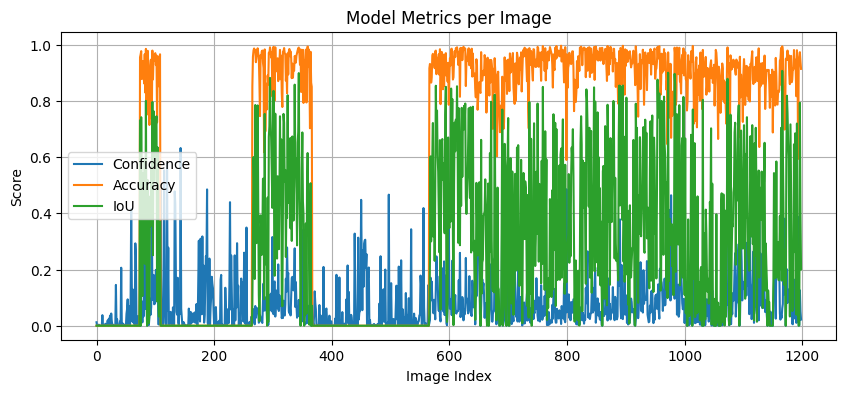

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Paths Setup:
# Define paths for the model, test images, ground truth masks, infrared images (optional), 
# and output directory where results will be saved.

# Model Path: Path to the pre-trained HRNet model (saved as .h5).
model_path = "/content/drive/MyDrive/landslide/algorithm/HRNet/hrnet_landslide_png1.h5"

# Test Images Path: Directory containing the test images.
test_dir = "/content/drive/MyDrive/land test/images"

# Masks Path: Directory containing the ground truth masks.
mask_dir = "/content/drive/MyDrive/land test/Masks"

# Infrared Images Path: Optional path for infrared images to enhance predictions (if available).
infrared_dir = "/content/drive/MyDrive/landslide/algorithm/HRNet/infrared"  # Optional

# Output Directory: Directory where results (visualizations) will be stored.
output_dir = "/content/drive/MyDrive/landslide/algorithm/HRNet/resultsLWANet_combined"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Model Loading:
# Load the pre-trained HRNet model from the saved file without compiling it (using `load_model` function).
model = load_model(model_path, compile=False)

# Load image paths:
# Get all test image paths from the test directory.
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))

# Image Size:
# Set the target size for input images.
img_size = (128, 128)

def combined_predict_visualize(image_paths, model, img_size, mask_dir, infrared_dir=None, output_dir='results', max_images=50):
    """
    Function to process the images and generate visualizations including ground truth,
    predicted masks, contours, and performance metrics (Accuracy, IoU).
    
    Args:
    - image_paths (list): List of file paths to the test images.
    - model (keras.Model): Pre-trained model to use for predictions.
    - img_size (tuple): The target size for the images.
    - mask_dir (str): Directory containing the ground truth masks.
    - infrared_dir (str, optional): Directory containing infrared images for enhanced predictions.
    - output_dir (str): Directory to save the results.
    - max_images (int): Maximum number of images to process.
    """
    avg_confidences = []
    all_accuracies = []
    all_ious = []

    print(f"Processing {min(len(image_paths), max_images)} images...\n")

    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, img_name)
        ir_path = os.path.join(infrared_dir, img_name) if infrared_dir else None

        # Load RGB image:
        # Load the image, resize it, and normalize the pixel values.
        rgb_img = load_img(img_path, target_size=img_size)
        rgb_array = img_to_array(rgb_img) / 255.0
        input_tensor = np.expand_dims(rgb_array, axis=0)

        # Load infrared image if exists:
        # Load infrared image if the path is provided and the image exists.
        ir_array = None
        if ir_path and os.path.exists(ir_path):
            ir_img = load_img(ir_path, target_size=img_size, color_mode='grayscale')
            ir_array = img_to_array(ir_img).squeeze() / 255.0

        # Ground truth mask:
        # Load the ground truth mask if available, convert to binary mask.
        bin_mask = np.zeros(img_size, dtype=np.uint8)
        has_mask = os.path.exists(mask_path)
        if has_mask:
            gt_mask = load_img(mask_path, target_size=img_size, color_mode='grayscale')
            gt_array = img_to_array(gt_mask).squeeze() / 255.0
            bin_mask = (gt_array > 0.5).astype(np.uint8)

        # Prediction:
        # Use the model to predict the mask for the current image.
        pred = model.predict(input_tensor)[0, :, :, 0]
        bin_pred = (pred > 0.5).astype(np.uint8)
        avg_conf = np.mean(pred)
        avg_confidences.append(avg_conf)

        # Metrics:
        # Calculate Pixel Accuracy and IoU if ground truth mask is available.
        if has_mask:
            pixel_accuracy = np.mean(bin_pred == bin_mask)
            intersection = np.logical_and(bin_pred, bin_mask).sum()
            union = np.logical_or(bin_pred, bin_mask).sum()
            iou = intersection / union if union != 0 else 0
        else:
            pixel_accuracy = iou = 0

        all_accuracies.append(pixel_accuracy)
        all_ious.append(iou)

        # Visualization with contours and boxes:
        # Draw contours and bounding boxes for predicted landslide areas.
        vis_img = (rgb_array * 255).astype(np.uint8)
        vis_img = cv2.cvtColor(vis_img, cv2.COLOR_RGB2BGR)
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cv2.contourArea(cnt) > 10:
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.drawContours(vis_img, [cnt], -1, (0, 0, 255), 1)
                cv2.rectangle(vis_img, (x, y), (x+w, y+h), (255, 0, 0), 1)
                cv2.putText(vis_img, "Landslide Path", (x, y-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)

        # Plot:
        # Plot the original image, infrared image, prediction heatmap, predicted mask,
        # ground truth mask, and contours/bounding boxes.
        num_cols = 6 if ir_array is not None else 5
        fig, axes = plt.subplots(1, num_cols, figsize=(22, 4))
        fig.suptitle(f"{img_name} | Conf: {avg_conf:.3f} | Acc: {pixel_accuracy:.3f} | IoU: {iou:.3f}", fontsize=12)

        axes[0].imshow(rgb_array)
        axes[0].set_title("RGB Image")
        axes[0].axis("off")

        col_idx = 1
        if ir_array is not None:
            axes[col_idx].imshow(ir_array, cmap='hot')
            axes[col_idx].set_title("Infrared Image")
            axes[col_idx].axis("off")
            col_idx += 1

        axes[col_idx].imshow(pred, cmap="jet")
        axes[col_idx].set_title("Prediction Heatmap")
        axes[col_idx].axis("off")

        axes[col_idx+1].imshow(bin_pred, cmap="gray")
        axes[col_idx+1].set_title("Predicted Mask")
        axes[col_idx+1].axis("off")

        axes[col_idx+2].imshow(bin_mask, cmap="gray")
        axes[col_idx+2].set_title("Ground Truth")
        axes[col_idx+2].axis("off")

        axes[col_idx+3].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        axes[col_idx+3].set_title("Contours & Boxes")
        axes[col_idx+3].axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"combined_{idx:03d}_{img_name}"))
        plt.close()

    # Metrics Summary:
    # After processing the images, plot the model's performance metrics (Confidence, Accuracy, IoU) for each image.
    # This summary plot gives an overall view of how well the model performed across all images.
    plt.figure(figsize=(10, 4))
    plt.plot(avg_confidences, label='Confidence')
    plt.plot(all_accuracies, label='Accuracy')
    plt.plot(all_ious, label='IoU')
    plt.xlabel("Image Index")
    plt.ylabel("Score")
    plt.title("Model Metrics per Image")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, "metrics_summary.png"))
    plt.show()

# Run:
# Run the function to process and visualize results for the test images.
# The function can process up to `max_images` images (e.g., 1600).
# Each image's results are saved to the output directory.
combined_predict_visualize(
    image_paths=image_paths,
    model=model,
    img_size=img_size,
    mask_dir=mask_dir,
    infrared_dir=infrared_dir,
    output_dir=output_dir,
    max_images=1600
)


Explanation in the comments:
Paths: Paths to the pre-trained model, test images, and optional directories for infrared images and masks.

Model Loading: The model is loaded using load_model() for inference purposes (no need for compilation).

Image Preprocessing: Each test image is resized to the target shape (128, 128) and normalized to a range of [0, 1] for the model input.

Prediction and Contour Analysis: The model predicts a binary mask for each image. The contours of the mask are analyzed using OpenCV to detect if there are any significant areas (landslides).

Result Counting: The code counts the number of images where landslides are detected versus where they are not.

Summary: After processing the images, a summary is printed showing the total images processed and the count of landslides detected.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob
import cv2

# Paths
model_path = "/content/drive/MyDrive/landslide/algorithm/HRNet/hrnet_landslide_png1.h5"  # Path to the trained model
test_dir = "/content/drive/MyDrive/land test/images"  # Directory with test images
mask_dir = "/content/drive/MyDrive/land test/Masks"  # Directory with ground truth masks (optional for validation)
infrared_dir = "/content/drive/MyDrive/landslide/algorithm/HRNet/infrared"  # Optional directory with infrared images for additional analysis

# Load model
model = load_model(model_path, compile=False)  # Load the pre-trained model (do not compile for inference)

# Load image paths
image_paths = sorted(glob(os.path.join(test_dir, "*.png")))  # Get all image paths (sorted)
img_size = (128, 128)  # Target image size for processing

# Function to analyze the presence of landslides
def analyze_landslide_presence(image_paths, model, img_size, mask_dir, infrared_dir=None, max_images=50):
    landslide_count = 0  # Counter for images with landslides
    no_landslide_count = 0  # Counter for images without landslides

    print(f"Processing {min(len(image_paths), max_images)} images...\n")

    # Loop over each image in the directory (up to max_images)
    for idx, img_path in enumerate(image_paths[:max_images]):
        img_name = os.path.basename(img_path)  # Get the image name
        ir_path = os.path.join(infrared_dir, img_name) if infrared_dir else None  # Check if infrared image exists

        # Load the RGB image and preprocess it
        rgb_img = load_img(img_path, target_size=img_size)  # Load image and resize to target size
        rgb_array = img_to_array(rgb_img) / 255.0  # Convert image to array and normalize to [0, 1]
        input_tensor = np.expand_dims(rgb_array, axis=0)  # Add batch dimension for prediction

        # Predict the mask from the model
        pred = model.predict(input_tensor, verbose=0)[0, :, :, 0]  # Predict and get the first channel (grayscale)
        bin_pred = (pred > 0.5).astype(np.uint8)  # Threshold the prediction to get a binary mask

        # Contour analysis to detect landslide
        contours, _ = cv2.findContours(bin_pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Find external contours
        has_landslide = any(cv2.contourArea(cnt) > 10 for cnt in contours)  # If any contour area is large enough, it's a landslide

        if has_landslide:
            landslide_count += 1  # Increment landslide count if landslide is detected
        else:
            no_landslide_count += 1  # Increment no landslide count if no landslide is detected

    # Print summary of the results
    total_images = min(len(image_paths), max_images)  # Get the total number of processed images (up to max_images)
    summary_text = f"Total Images Processed: {total_images}\n" \
                   f"Landslide Detected: {landslide_count}\n" \
                   f"No Landslide Detected: {no_landslide_count}\n"

    print(summary_text)  # Print the summary of results

# Run the landslide presence analysis
analyze_landslide_presence(
    image_paths=image_paths,  # List of image paths to process
    model=model,  # Loaded pre-trained model
    img_size=img_size,  # Target size for images
    mask_dir=mask_dir,  # Directory containing ground truth masks (if available)
    infrared_dir=infrared_dir,  # Directory with infrared images (optional)
    max_images=1600  # Maximum number of images to process
)


Processing 1199 images...

Total Images Processed: 1199
Landslide Detected: 1007
No Landslide Detected: 192

